## Can be used in categorical and numeric also

1. easy but have to do in pd as not available in sklearn
2. we randomly select the value from the values present in that col so the distribution will remain amost same which is very good for linear algos as tyare data nu distribution matters so it shouldnt change much 
3. Covariance disturb thay
4. Memory heavy for deployment as koi null value che to aene replace karva aapde randomly select
5. So the percent of null doesnt matter distribution affect na thay

Decision tree vada ma na karay

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [3]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [4]:
df.isnull().mean() * 100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [5]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [7]:
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [8]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [9]:
null_mask_train = X_train['Age_imputed'].isnull()
X_train.loc[null_mask_train, 'Age_imputed'] = X_train['Age'].dropna().sample(null_mask_train.sum(), random_state=42).values

null_mask_test = X_test['Age_imputed'].isnull()
X_test.loc[null_mask_test, 'Age_imputed'] = X_train['Age'].dropna().sample(null_mask_test.sum(), random_state=42).values

# ahiya basically lhs ma Age_imputed ma aej rows select thase j null value hase in age_imputed col
# in rhs aaapde Age col mathi remove karye cheye null and main ma have not null hase badhu so rows missing hase so not null j banayu ae value mukase randomly and ae ne as np arr present karyu with .values

In [10]:
X_train['Age'].isnull().sum()

np.int64(148)

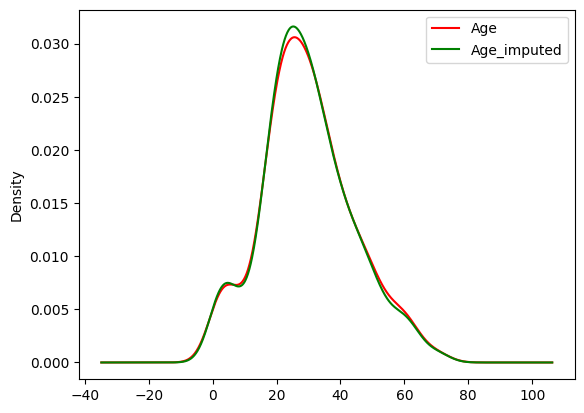

In [11]:
X_train['Age'].plot.density(color='red')
X_train['Age_imputed'].plot.density(color='green')
plt.legend()

In [12]:
X_train[['Fare','Age','Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,53.259863
Age,71.512440,204.349513,204.349513
Age_imputed,53.259863,204.349513,200.028966


<Axes: >

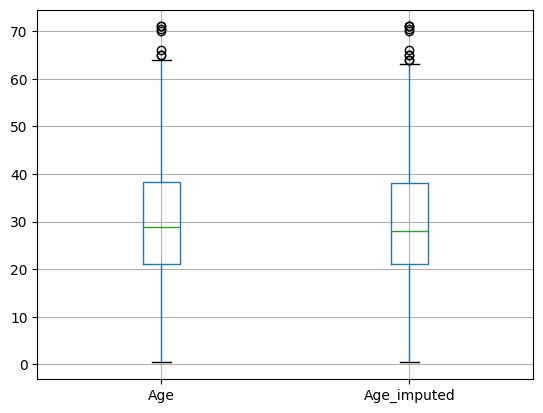

In [13]:
X_train[['Age', 'Age_imputed']].boxplot()

In [14]:
for idx, observation in X_train[X_train['Age'].isnull()].iterrows():
    X_train.loc[idx, 'Age_imputed'] = X_train['Age'].dropna().sample(1, random_state=int(observation['Fare'])).values[0]# pick 1 random observation from fare taki aek fare ni value ma aek age aave j randomly select thyi hoy  for eg fare 50 mate age 60 randomly select thyi so every time user puts fare 50 and age null then age 60 rehse.... this is better approach
    # row index and value aave series ma to values[0] will store the value only in np arr

for idx,observation in X_test[X_test['Age'].isnull()].iterrows():
    X_test.loc[idx,'Age_imputed'] = X_train['Age'].dropna().sample(1,random_state=int(observation['Fare'])).values[0]

## For categorical data

In [15]:
data = pd.read_csv('train (1).csv',usecols=['GarageQual','FireplaceQu','SalePrice'])

In [16]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [17]:
data.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [18]:
X = data
y = data['SalePrice']

In [19]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [20]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [21]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

C:\Users\MAANSHA\AppData\Local\Temp\ipykernel_26756\856878696.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQu

In [22]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),# counts how many times each category appears
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']
temp

,original,imputed
TA,0.950450,0.950342
Fa,0.036036,0.036815
Gd,0.009009,0.008562
Po,0.002703,0.002568
Ex,0.001802,0.001712


In [23]:
temp1 = pd.concat([
    X_train['FireplaceQu'].value_counts()/len(X_train['FireplaceQu'].dropna()),
    X_test['FireplaceQu'].value_counts()/len(X_train['FireplaceQu'].dropna())
])

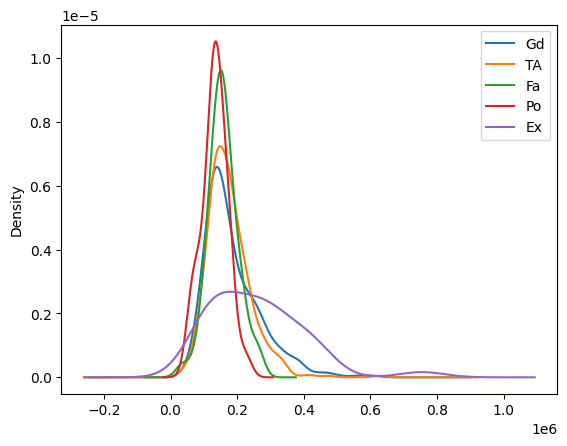

In [24]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    X_train[X_train['FireplaceQu_imputed']==category]['SalePrice'].plot.density(label=category)
    plt.legend()

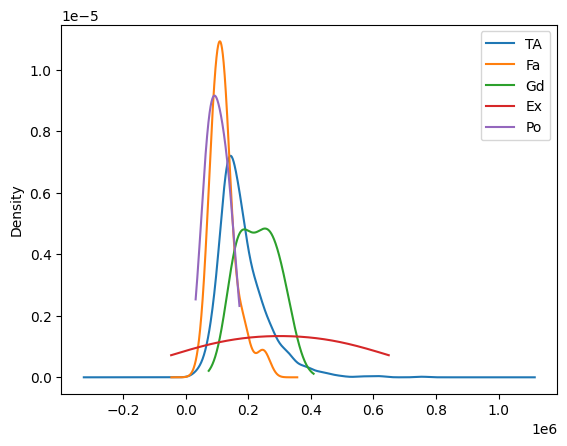

In [25]:
for c in X_train['GarageQual_imputed'].dropna().unique():
    X_train[X_train['GarageQual_imputed']==c]['SalePrice'].plot.density(label=c)
    plt.legend()